# Complete Book Rating Prediction Pipeline
This notebook walks through the full machine learning workflow:
1. Load and explore the raw data
2. Clean and preprocess
3. Engineer features and select the best ones
4. Train baseline and advanced models
5. Tune hyperparameters and evaluate
6. Interpret with SHAP and feature importance
7. Select the final model and export it for deployment

Every step explains **what** we do and **why** we do it.

In [1]:
# General imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, joblib, warnings
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin

# Advanced models
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
%cd ..

C:\Users\SMartWin\Desktop\DSTI\PythML\ML PROJECT\book_classification_pythonML


## 1. Load and Inspect the Raw Data

We load the dataset exactly as the standalone training script does – using the Python engine and warning on bad lines.

In [3]:
# Load the dataset
df = pd.read_csv('data/books.csv', engine='python', on_bad_lines='warn')
df.columns = df.columns.str.strip()
print(f"Shape: {df.shape}")
df.head()

Shape: (11119, 12)


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [4]:
# Basic statistics
df.describe(include='all')

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
count,11119.000000,11119,11119,11119.000000,11119,1.111900e+04,11119,11119.000000,1.111900e+04,11119.000000,11119,11119
unique,NaN,10344,6635,NaN,11119,NaN,27,NaN,NaN,NaN,3675,2289
top,NaN,The Iliad,Stephen King,NaN,0439785960,NaN,eng,NaN,NaN,NaN,10/1/2005,Vintage
freq,NaN,9,40,NaN,1,NaN,8906,NaN,NaN,NaN,56,318
mean,21308.966184,NaN,NaN,3.934135,NaN,9.759873e+12,NaN,336.439788,1.794832e+04,542.167371,NaN,NaN
std,13093.071002,NaN,NaN,0.350384,NaN,4.430554e+11,NaN,241.177969,1.125190e+05,2577.069549,NaN,NaN
min,1.000000,NaN,NaN,0.000000,NaN,8.987060e+09,NaN,0.000000,0.000000e+00,0.000000,NaN,NaN
25%,10277.500000,NaN,NaN,3.770000,NaN,9.780345e+12,NaN,192.000000,1.040000e+02,9.000000,NaN,NaN
50%,20287.000000,NaN,NaN,3.960000,NaN,9.780586e+12,NaN,299.000000,7.450000e+02,47.000000,NaN,NaN
75%,32103.500000,NaN,NaN,4.135000,NaN,9.780873e+12,NaN,416.000000,5.000500e+03,238.000000,NaN,NaN


In [5]:
# Missing values
df.isnull().sum()

bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
num_pages             0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

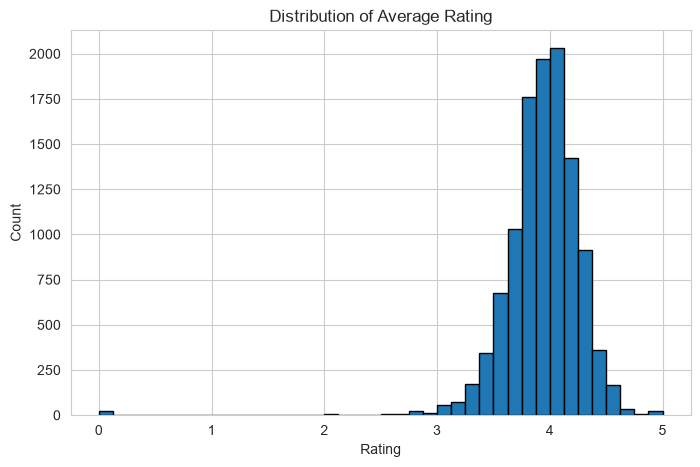

In [6]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))
df['average_rating'].hist(bins=40, edgecolor='black')
plt.title('Distribution of Average Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

## 2. Data Cleaning

We need to: parse dates, standardise language codes, split authors, cap outliers, and drop rows with missing targets.

In [7]:
def clean_dataframe(df):
    """Apply all cleaning steps to the raw dataframe."""
    initial_rows = len(df)
        # 1. Parse publication_date
    df['publication_date_parsed'] = pd.to_datetime(df['publication_date'], errors='coerce')
    df = df.dropna(subset=['publication_date_parsed']).copy()

    # 2. Standardize language codes
    df["language_code"] = (df["language_code"].str.lower().replace({
        "en-us": "eng",
        "en-gb": "eng",
        "en-ca": "eng"}))
    top_langs = ["eng", "spa", "fre", "ger", "jpn"]
    df["language_code"] = df["language_code"].apply(
    lambda x: x if x in top_langs else "other")

    # 3. Split authors
    df['author_count'] = df['authors'].apply(lambda x: len(str(x).split('/')))
    df['primary_author'] = df['authors'].apply(lambda x: str(x).split('/')[0].strip() if pd.notna(x) else '')

    # 4. Drop rows with missing target
    df.loc[df["average_rating"] == 0, "average_rating"] = np.nan
    df = df.dropna(subset=["average_rating"])

    # 5. Drop rows with ratings but no ratings_count.
    df = df[~((df["average_rating"] > 0) &
        (df["ratings_count"] == 0))]
    
    # 6. Enforce num_pages lies within the 1st and 99th percentile.
    cap_value = df['num_pages'].quantile(0.99)
    floor_value = df['num_pages'].quantile(0.01)
    df['num_pages'] = df['num_pages'].clip(lower=floor_value, upper=cap_value)
    
    # 7. Removing duplicates based on title and authors, keeping the one with the highest ratings_count.
    df[df.duplicated(subset=["title", "authors"], keep=False)].sort_values(["title", "authors"])
    df = (df.sort_values("ratings_count", ascending=False).drop_duplicates(subset=["title", "authors"], keep="first"))
   
    # 8. Replace old publication_date with parsed datetime
    df['publication_date'] = df['publication_date_parsed']
    df.drop('publication_date_parsed', axis=1, inplace=True, errors='ignore')
    df.drop('authors_clean', axis=1, inplace=True, errors='ignore')


    summary = {
        'initial_rows': initial_rows,
        'final_rows': len(df),
        'rows_removed': initial_rows - len(df),
        'cap_value': cap_value
    }
    return df, summary

# Apply cleaning
df_clean, clean_summary = clean_dataframe(df)
print(f"Cleaned dataset: {df_clean.shape}")
print(f"Dropped {clean_summary['rows_removed']} rows from original dataset, including those with unparseable dates, missing values, and duplicates.")
df_clean.head()

Cleaned dataset: (10729, 14)
Dropped 390 rows from original dataset, including those with unparseable dates, missing values, and duplicates.


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,author_count,primary_author
10333,41865,Twilight (Twilight #1),Stephenie Meyer,3.59,0316015849,9780316015844,eng,501.0,4597666,94265,2006-09-06,Little Brown and Company,1,Stephenie Meyer
1696,5907,The Hobbit or There and Back Again,J.R.R. Tolkien,4.27,0618260307,9780618260300,eng,366.0,2530894,32871,2002-08-15,Houghton Mifflin,1,J.R.R. Tolkien
1462,5107,The Catcher in the Rye,J.D. Salinger,3.80,0316769177,9780316769174,eng,277.0,2457092,43499,2001-01-30,Back Bay Books,1,J.D. Salinger
307,960,Angels & Demons (Robert Langdon #1),Dan Brown,3.89,1416524797,9781416524793,eng,736.0,2418736,21303,2006-04-01,Pocket Books,1,Dan Brown
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435.0,2339585,36325,2004-05-01,Scholastic Inc.,2,J.K. Rowling


## 3. Feature Engineering

We create new features from the title, dates, numeric columns, and categorical variables.

In [8]:
# Title features
def add_title_features(df):
    df['title_length'] = df['title'].astype(str).str.len()
    df['title_word_count'] = df['title'].astype(str).str.split().str.len()
    df['has_exclamation'] = df['title'].astype(str).str.contains('!').astype(int)
    return df

# Date features (reference year = 2026)
def add_datetime_features(df, reference_year=2026):
    df['publication_year'] = df['publication_date'].dt.year
    df['book_age'] = reference_year - df['publication_year']
    df['is_classic'] = (df['book_age'] > 50).astype(int)
    return df

# Numeric transforms
def add_numeric_transforms(df):
    df['log_ratings_count'] = np.log1p(df['ratings_count'])
    df['log_text_reviews_count'] = np.log1p(df['text_reviews_count'])
    df['reviews_per_rating'] = df['text_reviews_count'] / (df['ratings_count'] + 1)
    df.drop(columns=['ratings_count','text_reviews_count'], inplace=True, errors='ignore')
    return df

# Group rare categories
def group_rare_categories(df, column, threshold=5, other_name='Other'):
    counts = df[column].value_counts()
    rare = counts[counts <= threshold].index
    return df[column].apply(lambda x: other_name if x in rare else x)

# Smoothed target encoding
def target_encode_smooth(df, column, target, alpha=10.0):
    global_mean = df[target].mean()
    agg = df.groupby(column)[target].agg(['sum', 'count'])
    encoded_vals = (agg['sum'] + alpha * global_mean) / (agg['count'] + alpha)
    mapping = encoded_vals.to_dict()
    return df[column].map(mapping), mapping

print("Feature engineering functions ready.")

Feature engineering functions ready.


In [9]:
# Apply feature engineering
df_feat = df_clean.copy()
df_feat = add_title_features(df_feat)
df_feat = add_datetime_features(df_feat, 2026)
df_feat = add_numeric_transforms(df_feat)

# Group rare categories and target encode
for col, thresh in [('publisher', 5), ('primary_author', 3), ('language_code', 3)]:
    df_feat[col+'_grouped'] = group_rare_categories(df_feat, col, threshold=thresh)

encodings = {}
for col in ['publisher_grouped', 'primary_author_grouped', 'language_code_grouped']:
    encoded, mapping = target_encode_smooth(df_feat, col, 'average_rating', alpha=10.0)
    te_col = col.replace('_grouped', '_te')
    df_feat[te_col] = encoded
    encodings[col] = mapping

# Drop original raw columns that are now encoded
cols_to_drop = ['publisher_grouped', 'primary_author_grouped', 'language_code_grouped',
                'authors', 'primary_author', 'publisher', 'language_code',
                'publication_date', 'bookID', 'isbn', 'isbn13', 'title']
df_feat.drop(cols_to_drop, axis=1, inplace=True, errors='ignore')

# Ensure numeric only (just in case)
non_num = df_feat.select_dtypes(include=['object', 'category', 'datetime64']).columns
df_feat.drop(columns=non_num, inplace=True, errors='ignore')
print(f"Engineered feature matrix shape: {df_feat.shape}")
df_feat.head()

Engineered feature matrix shape: (10729, 15)


,average_rating,num_pages,author_count,title_length,title_word_count,has_exclamation,publication_year,book_age,is_classic,log_ratings_count,log_text_reviews_count,reviews_per_rating,publisher_te,primary_author_te,language_code_te
10333,3.59,501.0,1,23,3,0,2006,20,0,15.341060,11.453876,0.020503,3.970850,3.923635,3.940891
1696,4.27,366.0,1,35,7,0,2002,24,0,14.744084,10.400377,0.012988,4.002828,4.160292,3.940891
1462,3.80,277.0,1,22,5,0,2001,25,0,14.714490,10.680516,0.017703,3.881837,3.954492,3.940891
307,3.89,736.0,1,36,6,0,2006,20,0,14.698756,9.966650,0.008807,3.891810,3.883318,3.940891
3,4.56,435.0,2,59,10,0,2004,22,0,14.665485,10.500289,0.015526,4.006493,4.351364,3.940891


## 4. Feature Selection

We use mutual information and Recursive Feature Elimination (RFE) to keep the most important features.

In [10]:
X = df_feat.drop(columns=['average_rating'])
y = df_feat['average_rating']

# Mutual information
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# RFE with Ridge
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
rfe_estimator = Ridge(alpha=1.0)
rfe = RFE(rfe_estimator, n_features_to_select=max(len(X.columns)//2, 1))
rfe.fit(X_scaled, y)
selected = [f for f, s in zip(X.columns, rfe.support_) if s and mi_series[f] > 0.001]
print(f"Selected features ({len(selected)}): {selected}")

# Keep only selected + target
df_final = df_feat[selected + ['average_rating']]
df_final.head()

Selected features (7): ['num_pages', 'title_length', 'publication_year', 'log_ratings_count', 'log_text_reviews_count', 'publisher_te', 'primary_author_te']


,num_pages,title_length,publication_year,log_ratings_count,log_text_reviews_count,publisher_te,primary_author_te,average_rating
10333,501.0,23,2006,15.341060,11.453876,3.970850,3.923635,3.59
1696,366.0,35,2002,14.744084,10.400377,4.002828,4.160292,4.27
1462,277.0,22,2001,14.714490,10.680516,3.881837,3.954492,3.80
307,736.0,36,2006,14.698756,9.966650,3.891810,3.883318,3.89
3,435.0,59,2004,14.665485,10.500289,4.006493,4.351364,4.56


## 5. Train/Test Split

In [11]:
X = df_final[selected]
y = df_final['average_rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (8583, 7), Test size: (2146, 7)


## 6. Baseline Models

We train simple models (Dummy, Linear, Ridge, Lasso) to establish a performance floor.

In [12]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    return {
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test)
    }

def cross_val_rmse(model, X, y, cv=5):
    try:
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error')
        return -scores.mean(), scores.std()
    except:
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
        rmse = np.sqrt(-scores)
        return rmse.mean(), rmse.std()

baselines = {
    'Dummy': DummyRegressor(strategy='mean'),
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0, max_iter=10000)
}
base_results = []
for name, model in baselines.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    metrics = evaluate_model(pipe, X_train, X_test, y_train, y_test)
    cv_mean, cv_std = cross_val_rmse(pipe, X, y)
    metrics['Model'] = name
    metrics['CV RMSE Mean'] = cv_mean
    base_results.append(metrics)

df_base = pd.DataFrame(base_results)
df_base.to_csv('reports/baseline_model_comparison.csv', index=False)
df_base

,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R²,Test R²,Model,CV RMSE Mean
0,0.295632,0.297398,0.223527,0.228107,0.00000,-0.000186,Dummy,0.291972
1,0.245289,0.248484,0.177140,0.182508,0.31158,0.301765,Linear,0.239451
2,0.245289,0.248486,0.177137,0.182510,0.31158,0.301752,Ridge,0.239451
3,0.295632,0.297398,0.223527,0.228107,0.00000,-0.000186,Lasso,0.291972


## 7. Advanced Model Tuning

We tune Random Forest, XGBoost, LightGBM, and CatBoost using RandomizedSearchCV with 5‑fold CV.

In [ ]:
def build_advanced_models():
    rf = RandomForestRegressor(random_state=42)
    xgb_reg = xgb.XGBRegressor(random_state=42, verbosity=0)
    lgb_reg = lgb.LGBMRegressor(random_state=42, verbose=-1)
    cb_reg = cb.CatBoostRegressor(random_state=42, verbose=0)
    grids = {
        'RandomForest': (rf, {
            'n_estimators': [100,200,300], 'max_depth': [5,10,15,None],
            'min_samples_leaf': [1,3,5], 'min_samples_split': [2,5,10]
        }),
        'XGBoost': (xgb_reg, {
            'n_estimators': [100,200,300], 'learning_rate': [0.01,0.05,0.1],
            'max_depth': [3,5,7,10], 'subsample': [0.7,0.8,1.0]
        }),
        'LightGBM': (lgb_reg, {
            'n_estimators': [100,200,300], 'learning_rate': [0.01,0.05,0.1],
            'max_depth': [3,5,7,-1], 'subsample': [0.7,0.8,1.0]
        }),
        'CatBoost': (cb_reg, {
            'iterations': [100,200,300], 'learning_rate': [0.01,0.05,0.1],
            'depth': [4,6,8,10]
        })
    }
    return grids

advanced = build_advanced_models()
adv_results = []
best_models = {}

for name, (model, param_grid) in advanced.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(model, param_grid, n_iter=20, cv=5,
                                scoring='neg_root_mean_squared_error',
                                random_state=42, n_jobs=-1, verbose=0)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    metrics = evaluate_model(best, X_train, X_test, y_train, y_test)
    cv_rmse = -search.best_score_
    metrics['Model'] = name
    metrics['CV RMSE'] = cv_rmse
    metrics['Best Params'] = str(search.best_params_)
    adv_results.append(metrics)
    best_models[name] = best
    joblib.dump(best, f'models/model_{name.replace(" ","_").lower()}.joblib')
    print(f"  {name} CV RMSE: {cv_rmse:.4f}")

df_adv = pd.DataFrame(adv_results)
df_adv.to_csv('reports/advanced_model_comparison.csv', index=False)
df_adv

Tuning RandomForest...
  RandomForest CV RMSE: 0.2402
Tuning XGBoost...
  XGBoost CV RMSE: 0.2405
Tuning LightGBM...
  LightGBM CV RMSE: 0.2400
Tuning CatBoost...


## 8. Model Evaluation & Interpretation

For each advanced model, we generate: residual plot, predicted vs actual, error by rating band, feature importance, and SHAP summary.

In [ ]:
def deep_evaluation(model, X_test, y_test, model_name, selected_features, output_dir='reports/report_latex/figures'):
    os.makedirs(output_dir, exist_ok=True)
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    # 1. Residual plot
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residual Plot – {model_name}')
    plt.xlabel('Predicted Rating')
    plt.ylabel('Residual')
    plt.savefig(os.path.join(output_dir, f'{model_name}_residual.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # 2. Predicted vs Actual
    plt.figure(figsize=(8,8))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'Predicted vs Actual – {model_name}')
    plt.xlabel('Actual Rating')
    plt.ylabel('Predicted Rating')
    plt.savefig(os.path.join(output_dir, f'{model_name}_pred_vs_actual.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # 3. Error by rating band
    bins = [0,2,3,4,5]
    labels = ['0-2','2-3','3-4','4-5']
    df_eval = pd.DataFrame({'actual': y_test, 'predicted': y_pred})
    df_eval['band'] = pd.cut(df_eval['actual'], bins=bins, labels=labels)
    error_band = df_eval.groupby('band').apply(lambda x: np.sqrt(mean_squared_error(x['actual'], x['predicted'])))
    plt.figure(figsize=(8,5))
    error_band.plot(kind='bar')
    plt.title(f'RMSE by Rating Band – {model_name}')
    plt.savefig(os.path.join(output_dir, f'{model_name}_error_band.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # 4. Feature importance (if tree-based)
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=selected_features).sort_values(ascending=False)
        plt.figure(figsize=(10,6))
        imp.plot(kind='bar')
        plt.title(f'Feature Importance – {model_name}')
        plt.savefig(os.path.join(output_dir, f'{model_name}_importance.png'), dpi=150, bbox_inches='tight')
        plt.show()
        imp.to_json(os.path.join(output_dir, f'{model_name}_importance.json'))

    # 5. SHAP values (if shap is installed)
    try:
        import shap
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        np.save(os.path.join(output_dir, f'{model_name}_shap_values.npy'), shap_values)
        plt.figure()
        shap.summary_plot(shap_values, X_test, show=False)
        plt.title(f'SHAP Summary – {model_name}')
        plt.savefig(os.path.join(output_dir, f'{model_name}_shap_summary.png'), dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"SHAP failed for {model_name}: {e}")

# Run deep evaluation for each tuned model
for name in best_models.keys():
    print(f"Evaluating {name}...")
    deep_evaluation(best_models[name], X_test, y_test, name, selected)
print("All evaluation plots generated.")

## 9. Ensemble & Final Model Selection

We try a simple average of RandomForest and LightGBM, then pick the model with the lowest test RMSE.

In [ ]:
rf = best_models['RandomForest']
lgbm = best_models['LightGBM']
ens_pred = (rf.predict(X_test) + lgbm.predict(X_test)) / 2
ens_rmse = np.sqrt(mean_squared_error(y_test, ens_pred))
ens_mae = mean_absolute_error(y_test, ens_pred)
ens_r2 = r2_score(y_test, ens_pred)
print(f"Ensemble Test RMSE: {ens_rmse:.4f}, R²: {ens_r2:.4f}")

# Choose final model
best_adv = min(adv_results, key=lambda x: x['Test RMSE'])
if ens_rmse < best_adv['Test RMSE']:
    final_model = type('Ensemble', (object,), {'predict': lambda self, X: (rf.predict(X)+lgbm.predict(X))/2})()
    final_name = 'Ensemble (RF+LGBM)'
else:
    final_name = best_adv['Model']
    final_model = best_models[final_name]

print(f"Final model: {final_name}")
joblib.dump(final_model, 'models/best_model.joblib')

## 10. Export Full Pipeline for Deployment

We wrap the preprocessing steps and the final model into a single sklearn Pipeline and save it with joblib.

In [ ]:
class BookRatingPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, reference_year=2026, target='average_rating', feature_list_path='models/feature_names.json'):
        self.reference_year = reference_year
        self.target = target
        self.feature_list_path = feature_list_path
        self._metadata = None
        self._feature_names = None

    def fit(self, X, y=None):
        df = X.copy()
        df_clean, _ = clean_dataframe(df)
        df = add_title_features(df_clean)
        df = add_datetime_features(df, self.reference_year)
        df = add_numeric_transforms(df)
        for col, thresh in [('publisher', 5), ('primary_author', 3), ('language_code', 3)]:
            df[col+'_grouped'] = group_rare_categories(df, col, threshold=thresh)
        target_encodings = {}
        for col in ['publisher_grouped', 'primary_author_grouped', 'language_code_grouped']:
            encoded, mapping = target_encode_smooth(df, col, self.target, alpha=10.0)
            te_col = col.replace('_grouped', '_te')
            df[te_col] = encoded
            target_encodings[col] = mapping
        self._metadata = {'target_encodings': target_encodings}
        with open(self.feature_list_path) as f:
            self._feature_names = json.load(f)
        return self

    def transform(self, X):
        df = X.copy()
        df_clean, _ = clean_dataframe(df)
        df = add_title_features(df_clean)
        df = add_datetime_features(df, self.reference_year)
        df = add_numeric_transforms(df)
        for col, thresh in [('publisher', 5), ('primary_author', 3), ('language_code', 3)]:
            df[col+'_grouped'] = group_rare_categories(df, col, threshold=thresh)
        for col in ['publisher_grouped', 'primary_author_grouped', 'language_code_grouped']:
            te_col = col.replace('_grouped', '_te')
            mapping = self._metadata['target_encodings'].get(col, {})
            df[te_col] = df[col].map(mapping)
            fill_val = np.mean(list(mapping.values())) if mapping else 0
            df[te_col].fillna(fill_val, inplace=True)
        df.drop(['publisher_grouped', 'primary_author_grouped', 'language_code_grouped'], axis=1, errors='ignore')
        for col in ['authors', 'primary_author', 'publisher', 'language_code']:
            df.drop(col, axis=1, inplace=True, errors='ignore')
        df.drop(['publication_date', 'bookID', 'isbn', 'isbn13', 'title'], axis=1, inplace=True, errors='ignore')
        non_num = df.select_dtypes(include=['object','category','datetime64']).columns
        df.drop(columns=non_num, inplace=True, errors='ignore')
        return df[self._feature_names]

# Save feature names used for final model
with open('models/feature_names.json', 'w') as f:
    json.dump(selected, f)

# Fit preprocessor on the original raw data
preprocessor = BookRatingPreprocessor()
preprocessor.fit(df)

# Build and save the full pipeline
full_pipeline = Pipeline([('preprocessor', preprocessor), ('model', final_model)])
joblib.dump(full_pipeline, 'models/best_pipeline.joblib')
print("Full pipeline saved as models/best_pipeline.joblib")

## 11. Generate Summary Reports

In [ ]:
# Write summary files
with open('reports/data_quality_summary.txt', 'w') as f:
    f.write(f"Initial rows: {clean_summary['initial_rows']}\n")
    f.write(f"Final rows after cleaning: {clean_summary['final_rows']}\n")
    f.write(f"Rows dropped: {clean_summary['rows_removed']}\n")

with open('reports/feature_engineering_summary.txt', 'w') as f:
    f.write(f"Selected features: {', '.join(selected)}\n")

with open('reports/final_evaluation_summary.txt', 'w') as f:
    f.write(f"Final model: {final_name}\n")
    f.write(f"Ensemble Test RMSE: {ens_rmse:.4f}, R²: {ens_r2:.4f}\n")
    f.write("Baseline results:\n")
    f.write(df_base.to_string())
    f.write("\nAdvanced results:\n")
    f.write(df_adv.to_string())

# Correlation heatmap for the report
corr_df = df_clean[['average_rating','num_pages','ratings_count','text_reviews_count']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('reports/report_latex/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("All reports and plots have been saved.")
print("Notebook completed. You can now use the trained model in the Streamlit app.")